In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

In [2]:
FILE = "data/antivirals.csv"
OUTPUT_FOLDER = "results"
db = pd.read_csv(FILE)
db.columns

Index(['ligand_chembl_id', 'min_value', 'max_value', 'avg', 'activity_comment',
       'max_phase', 'target_chembl_id', 'target_accession', 'target_pref_name',
       'target_organism', 'assay_description', 'canonical_smiles',
       'molecular_weight'],
      dtype='object')

In [3]:
def clean_molecule(input_file, output_file):
    """
    Desalting, sin quiralidad -> reinvent.prior no interpreta quiralidad
    Quitan los duplicados SMILES
    """
    seen = set()
    with open(input_file, 'r') as f_in, open(output_file, 'w') as f_out:
        for line in f_in: 
            smi = line.strip()
            mol = Chem.MolFromSmiles(smi)
            # remover = Chem.SaltRemover()
            # res = remover.StripMol(mol, dontRemoveEverything=True)
            remover = rdMolStandardize.LargestFragmentChooser()
            res = remover.choose(mol)
            uncharger = rdMolStandardize.Uncharger()
            un = uncharger.uncharge(res)
            result = Chem.MolToSmiles(un, canonical=True, isomericSmiles=False)
            seen.add(result)
            f_out.write(result + '\n')

In [4]:
df_fusion_protein = db[db["target_organism"].notna()]
df_fusion_protein.to_csv(f"{OUTPUT_FOLDER}/fusion_protein.csv", index=False)
df_fusion_protein["canonical_smiles"].to_csv(f"{OUTPUT_FOLDER}/raw_fusion_protein.smi", header=False, index=False)
clean_molecule(f"{OUTPUT_FOLDER}/raw_fusion_protein.smi", f"{OUTPUT_FOLDER}/fusion_protein.smi")

df_viral_entry = db[db["target_organism"].isna()]
df_viral_entry.to_csv(f"{OUTPUT_FOLDER}/viral_entry.csv", index=False)
df_viral_entry["canonical_smiles"].to_csv(f"{OUTPUT_FOLDER}/raw_viral_entry.smi", header=False, index=False)
clean_molecule(f"{OUTPUT_FOLDER}/raw_viral_entry.smi", f"{OUTPUT_FOLDER}/viral_entry.smi")

db["canonical_smiles"].to_csv(f"{OUTPUT_FOLDER}/raw_antivirals.smi", header=False, index=False)
clean_molecule(f"{OUTPUT_FOLDER}/raw_antivirals.smi", f"{OUTPUT_FOLDER}/antivirals.smi")

[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Fragment: O=C(O)c1cc2ccccc2c(Cc2c(O)c(C(=O)O)cc3ccccc23)c1O
[14:07:28] New largest fragment: O=C(O)c1cc2ccccc2c(Cc2c(O)c(C(=O)O)cc3ccccc23)c1O (45)
[14:07:28] Fragment: OCCOCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1
[14:07:28] New largest fragment: OCCOCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1 (53)
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Uncharger
[14:07:28] Running LargestFragmentChooser
[14:07:28] Running Un

In [5]:
keywords_map = {
    "Human immunodeficiency virus 1": [
        "HIV-1", "HIV", "HIV1", "HIV 1", "Human immunodeficiency virus"
    ],
    "Measles virus": [
        "Measles virus"
    ],
    "Hepatitis B virus": [
        "HBV"
    ],
    "Machupo virus": [
        "Machupo virus"
    ],
    "Lassa virus": [
        "Lassa virus"
    ],
    "Junin virus": [
        "JUNV", "Junin virus"
    ],
    "Human adenovirus 5": [
        "Human adenovirus 5"
    ],
}

In [6]:
organism_map = {
    "Human immunodeficiency virus 1": "HIV-1",
    "Human immunodeficiency virus": "HIV-1",
    "Human immunodeficiency virus type 1 group M subtype B (isolate YU-2)(HIV-1)": "HIV-1",
    "Human immunodeficiency virus type 1 group M subtype B (isolate HXB2)(HIV-1)": "HIV-1",
    "Human respiratory syncytial virus": "RSV",
    "Human respiratory syncytial virus A (strain A2)": "RSV",
    "Ebolavirus": "Ebola virus",
    "Zaire ebolavirus (strain Mayinga-76) (ZEBOV) (Zaire Ebola virus)": "Ebola virus",
    "Severe acute respiratory syndrome coronavirus": "SARS-CoV",
    "Severe acute respiratory syndrome coronavirus 2": "SARS-CoV-2",
    "Hepatitis C virus": "HCV",
    "Hepatitis B virus": "HBV",
    "dengue virus type 2": "Dengue virus 2",
    "Influenza A virus": "Influenza A",
    "Human adenovirus 5": "Adenovirus 5",
    "Infectious hematopoietic necrosis virus": "IHNV",
    "Marburgvirus": "Marburg virus",
    "Vesicular stomatitis virus": "VSV"
}

In [7]:
def classify_unchecked(row):
    if row["target_pref_name"] != "Unchecked":
        return row["target_pref_name"]

    desc = str(row.get("assay_description", ""))
    for label, keywords in keywords_map.items():
        for kw in keywords:
            if kw in desc:
                return label
    return "Unchecked"

def add_organism(row):
    if not pd.isna(row["target_organism"]):
        return row["target_organism"]
    return row["target_pref_name"]

def replace_organism(row):
    actual_org = row["target_organism"]
    if actual_org in organism_map:
        return organism_map[actual_org]
    return actual_org

df = db.copy()
df["target_pref_name"] = df.apply(classify_unchecked, axis=1)
#df[df["target_pref_name"] == "Unchecked"][["target_pref_name", "assay_description"]]
df["target_organism"] = df.apply(add_organism, axis=1)
df["target_organism"] = df.apply(replace_organism, axis=1)
#df["target_organism"].value_counts()

In [8]:
df["target_organism"].value_counts()

target_organism
HIV-1             270
RSV               197
Machupo virus      74
Ebola virus        73
Influenza A        30
Lassa virus        19
HCV                12
Junin virus         9
Adenovirus 5        9
Dengue virus 2      6
IHNV                4
Marburg virus       2
Measles virus       2
SARS-CoV            1
HBV                 1
VSV                 1
SARS-CoV-2          1
Name: count, dtype: int64

In [9]:
df["molecular_weight"].mean()

np.float64(411.50344585091415)

In [10]:
np.log10(df["avg"].mean())

np.float64(3.1979435403138776)

In [11]:
COLOR = "#000"

<function matplotlib.pyplot.show(close=None, block=None)>

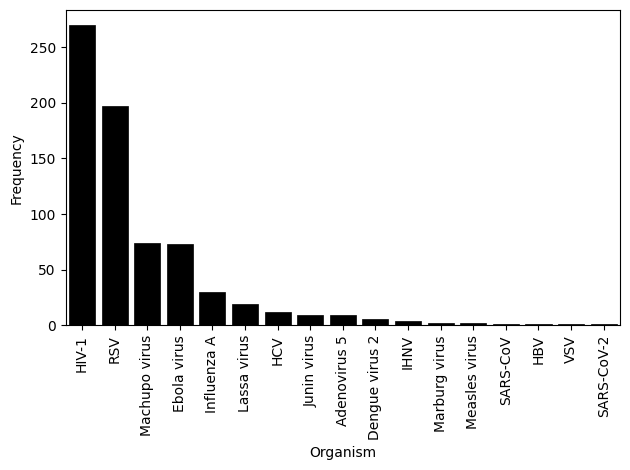

In [12]:
NAME = "hist_general_organism"
fig, ax = plt.subplots()
sns.countplot(
    data=df, 
    x="target_organism",
    order=df["target_organism"].value_counts().index, 
    ax=ax,
    color=COLOR,
    linewidth=0.5,
    edgecolor="black"
)
ax.set_title("")
ax.set_xlabel("Organism")
ax.set_ylabel("Frequency")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/{NAME}.png", dpi=300)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

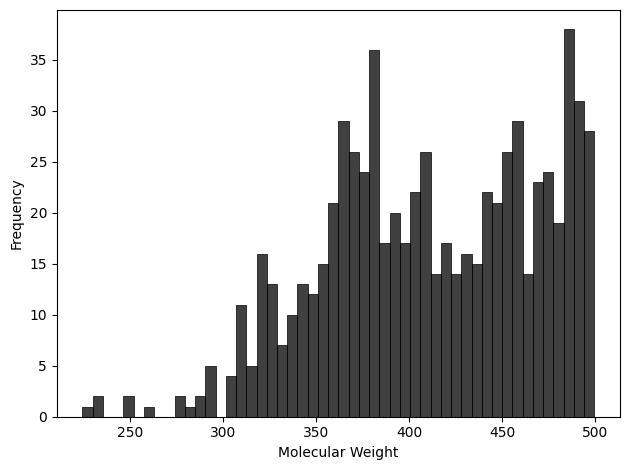

In [13]:
NAME = "hist_general_molecular_weight"
fig, ax = plt.subplots()
sns.histplot(
    data=df,
    x="molecular_weight",
    ax=ax,
    color=COLOR,
    linewidth=0.5,
    bins=50,
)
ax.set_title("")
ax.set_xlabel("Molecular Weight")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/{NAME}.png", dpi=300)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

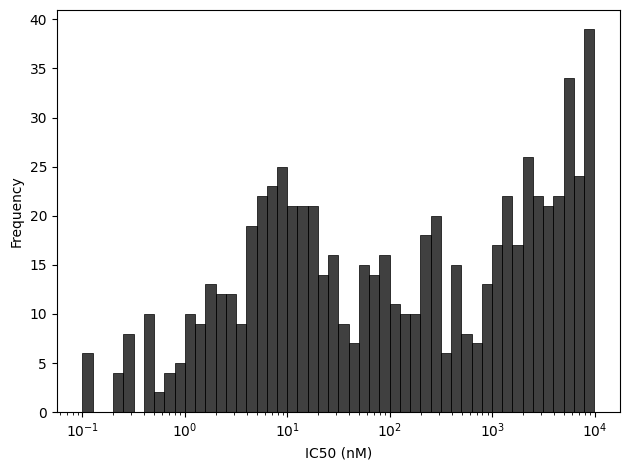

In [14]:
NAME = "hist_general_IC50"
fig, ax = plt.subplots()
sns.histplot(
    data=df,
    x="avg",
    ax=ax,
    color=COLOR,
    linewidth=0.5,
    log_scale=True,
    bins=50,
)
ax.set_title("")
ax.set_xlabel("IC50 (nM)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(f"{OUTPUT_FOLDER}/{NAME}.png", dpi=300)
plt.show